# Project name - FMCG Sales Drivers Analysis

## Statistical and Quasi-Causal Analysis of Sales Drivers in FMCG Retail: A Multivariate Study.

# 1. Problem Definition (Scientific Method)

## Research Question
    This project aims to answer the following core question:
    What affects sales?
    Which operational, environmental, and store-level factors significantly drive FMCG beverage sales?

    More specifically, we investigate which operational, environmental, and store-level factors significantly influence sales performance.
    
## Business & Analytical Motivation
    Understanding sales drivers is critical for FMCG companies because it enables:

    - Improved demand forecasting
    - Optimized field operations (store visits)
    - Better allocation of refrigeration and branding equipment
    - Data-driven retail strategy decisions
    - Increased revenue efficiency across stores and regions

    This project bridges business intelligence and statistical modeling to identify both correlation and causal relationships.

## Hypotheses
    We test the following hypotheses using statistical and machine learning methods:
    H1: Store Visits Effect
        - Store visits have a positive and statistically significant impact on sales.
    H2: Weather Impact
         - Weather conditions (temperature, precipitation, humidity) significantly influence beverage demand.
    H3: Store Execution Effect
        - Stores with better execution (equipment, branding, availability) generate higher sales.
    H4: Heterogeneity Across Stores
        - The effect of operational and environmental drivers varies across: 
        regions
        store segments
        trade channels

## Causality Considerations

    While the project aims to identify drivers of sales, it is important to distinguish between correlation and causation.

    Baseline statistical models (correlation, OLS) identify associations, but may suffer from:
    - Endogeneity
    - Omitted variable bias
    - Selection bias (e.g., high-performing stores may receive more visits)

    To address this, we extend the analysis using:
    - Lagged variables (temporal ordering)
    - Fixed Effects models (controlling for unobserved heterogeneity)

    These approaches improve causal interpretability, though results should still be interpreted with caution.

# 2. DATA ARCHITECTURE
    The project integrates multiple data sources into a unified analytical dataset.
    
## CORE DATA (Business Layer)
### 1. SALES (target dataset)
    Contains daily transactional performance per store:
    date
    customer (store ID)
    revenue_bgn (sales value in BGN)
    cases (volume sold)

    This is the main dependent variable used in all models.
## OPERATIONS LAYER
### 2. VISITS 
    Represents field activity:
    Customer
    date
    visits (number of executed store visits)

    Measures sales force intensity and retail engagement.
### 3. COOLER / EQUIPMENT
    Represents in-store execution quality:
    customer
    equipment count
    branding
    status

    Captures availability and visibility of products in-store.
## MASTER STORE DATA
### 4. LIST DATASET
    Provides static store characteristics:
    customer
    region
    city
    channel
    segment

    Explains structural differences between stores.
## EXTERNAL ENVIRONMENT
### 5. WEATHER
    Daily environmental conditions per region:
    date
    temperature (°C)
    precipitation (mm)
    humidity (%)
    wind (km/h)
    holiday
    weekend
    non working day

    Captures external demand-driving conditions.

# 3. DATA INGESTION & INITIAL INSPECTION

Data Loading Strategy (Multi-source ingestion)

The dataset is constructed using multiple heterogeneous data sources including sales, store information, operational visits, equipment data, and external weather data.

Each dataset is loaded independently from cloud storage (Google Drive) to ensure modularity and reproducibility of the pipeline.

This approach separates raw data ingestion from transformation logic,
improving maintainability and debuggability.

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import holidays
import time
import statsmodels.api as sm
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
import seaborn as sns

### DATA LOADING - RAW LAYER

In [2]:
# LOAD FROM GOOGLE DRIVE IDS

def load_drive(file_id, compression=None):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    return pd.read_csv(url, compression=compression)


sales = load_drive("1g-2KlxWBgJwlVULMSh1jmXvPrzgpI0tJ", compression="gzip")
store = load_drive("1JlVGwR1koth70guNf8fygJx207qhn9eZ")
visits = load_drive("1gC53aiUNdGl5Za2Y0kr-iDW6-UPQWs1d")
cooler = load_drive("18M8gADRTypnnqWZkjQnkhVcl3Y6H1AGg")

### INITIAL DATA INSPECTION

In [3]:
datasets = {
    "sales": sales,
    "visits": visits,
    "cooler": cooler,
    "store": store
}

for name, df in datasets.items():
    print("\n", "="*40)
    print(name.upper())
    print(df.head())
    print(df.info())
    print("Shape:", df.shape)


SALES
         date  customer revenue_bgn cases
0  2025-01-01    103335        13,9     5
1  2025-01-01    106635       61,14    22
2  2025-01-01    103263        13,9     5
3  2025-01-01    106943       11,12     4
4  2025-01-01    111148       61,14    22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662041 entries, 0 to 662040
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   date         662041 non-null  object
 1   customer     662041 non-null  int64 
 2   revenue_bgn  662041 non-null  object
 3   cases        662041 non-null  object
dtypes: int64(1), object(3)
memory usage: 20.2+ MB
None
Shape: (662041, 4)

VISITS
   Customer       date  Executed\nVisits All
0    111009  16.6.2025                     1
1    111009  24.6.2025                     2
2    111009  23.7.2025                     2
3    111009  12.8.2025                     1
4    111009  18.8.2025                     1
<class 'pandas.core.frame.

# 4. DATA CLEANING & STANDARDIZATION

After loading, all datasets undergo a standardized preprocessing pipeline to ensure structural consistency across sources.

This includes:

    - Standardization of column names (removal of hidden characters and formatting inconsistencies)
    - Harmonization of naming conventions across datasets (e.g., Customer → customer)
    - Conversion of numerical fields stored as strings into numeric format (e.g., revenue, cases)
    - Transformation of date fields into datetime format for downstream processing

This step ensures all datasets share a consistent schema prior to integration.

Time Alignment

All datasets are aligned at daily granularity using a unified date key (date),
ensuring temporal consistency and enabling reliable cross-source joins.

### COLUMN CLEANING

In [4]:
# remove hidden characters BEFORE everything else
def clean_cols(df):
    df.columns = (
        df.columns
        .str.replace("\n", " ")
        .str.replace("\r", " ")
        .str.strip()
    )
    return df

sales = clean_cols(sales)
visits = clean_cols(visits)
cooler = clean_cols(cooler)
store = clean_cols(store)

#print(df.head())

### RENAME COLUMNS - STANDARDIZATION LAYER

In [5]:
visits = visits.rename(columns={
    "Calendar day": "date",
    "Customer": "customer",
    "Executed Visits All": "visits"
})

store = store.rename(columns={
    "Customer": "customer"
})

cooler = cooler.rename(columns={
    "Customer": "customer",
    "Number of Equipments": "equipment_count"
})

### TYPE CONVERSION 

In [6]:
def clean_sales(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["revenue_bgn"] = (
        df["revenue_bgn"].astype(str).str.replace(",", ".").astype(float)
    )
    df["cases"] = pd.to_numeric(df["cases"], errors="coerce")
    return df

In [7]:
# SALES
sales = clean_sales(sales)

# VISITS
visits["date"] = pd.to_datetime(visits["date"], errors="coerce", dayfirst=True)
visits["visits"] = pd.to_numeric(visits["visits"], errors="coerce")

### DATA QUALITY CHECK 

In [8]:
print("SALES:", sales.columns.tolist())
print("VISITS:", visits.columns.tolist())
print("STORE:", store.columns.tolist())
print("COOLER:", cooler.columns.tolist())

SALES: ['date', 'customer', 'revenue_bgn', 'cases']
VISITS: ['customer', 'date', 'visits']
STORE: ['customer', 'Customer Name', 'Region', 'City', 'Trade Channel', 'Segment', 'Seasonal', 'Тype']
COOLER: ['customer', 'Type', 'Branding', 'Status', 'equipment_count', 'Number of doors']


### WEATHER PIPELINE (EXTERNAL DATA SOURCE)

In [9]:
def get_weather(city, lat, lon):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2025-01-01",
        "end_date": "2025-12-31",
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "relative_humidity_2m_mean",
            "windspeed_10m_max"
        ],
        "timezone": "Europe/Sofia"
    }

    r = requests.get(url, params=params)
    data = r.json()["daily"]

    df = pd.DataFrame(data)
    df["city"] = city
    return df


cities = {
     "Varna": (43.2141, 27.9147),
    "Burgas": (42.5048, 27.4626),
    "Shumen": (43.2712, 26.9361),
    "Ruse": (43.8356, 25.9657),
    "Sliven": (42.6818, 26.3227),
    "Veliko Tarnovo": (43.0757, 25.6172),
    "Yambol": (42.4840, 26.5030),
    "Targovishte": (43.2512, 26.5729),
    "Razgrad": (43.5333, 26.5167),
    "Dobrich": (43.5667, 27.8333),
    "Silistra": (44.1167, 27.2667),
    "Stara Zagora": (42.4258, 25.6345),
    "Plovdiv": (42.1354, 24.7453),
    "Pleven": (43.4170, 24.6067),
    "Gabrovo": (42.8747, 25.3342)
}

all_weather = []

for city, (lat, lon) in cities.items():
    print("Downloading:", city)
    df = get_weather(city, lat, lon)
    all_weather.append(df)
    time.sleep(1)
    
print("Download completed.")

weather = pd.concat(all_weather, ignore_index=True)

weather = weather.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temperature_celsius",
    "precipitation_sum": "precipitation_mm",
    "relative_humidity_2m_mean": "humidity_percent",
    "windspeed_10m_max": "wind_speed_kmh"
})

weather["date"] = pd.to_datetime(weather["date"])

Downloading: Varna
Downloading: Burgas
Downloading: Shumen
Downloading: Ruse
Downloading: Sliven
Downloading: Veliko Tarnovo
Downloading: Yambol
Downloading: Targovishte
Downloading: Razgrad
Downloading: Dobrich
Downloading: Silistra
Downloading: Stara Zagora
Downloading: Plovdiv
Downloading: Pleven
Downloading: Gabrovo
Download completed.


# 5. DATA INTEGRATION & CROSS-SOURCE MAPPING

### Region–Weather Mapping Logic

Weather data is not directly available per store, but only per city.

However, store-level data contains regional identifiers in Bulgarian language, while weather dataset uses English city names.

To resolve this mismatch, a mapping layer is introduced:

    Bulgarian Region → English City Name mapping

Example:

    “Варна” → “Varna”
    “Бургас” → “Burgas”

This mapping ensures correct alignment between:

    Store location (business layer)
    Weather conditions (external environment layer)

In [10]:
# REGION → CITY MAPPING 

region_to_city = {
    "Варна": "Varna",
    "Бургас": "Burgas",
    "Шумен": "Shumen",
    "Русе": "Ruse",
    "Сливен": "Sliven",
    "Велико Търново": "Veliko Tarnovo",
    "Ямбол": "Yambol",
    "Търговище": "Targovishte",
    "Разград": "Razgrad",
    "Добрич": "Dobrich",
    "Силистра": "Silistra",
    "Стара Загора": "Stara Zagora",
    "Пловдив": "Plovdiv",
    "Плевен": "Pleven",
    "Габрово": "Gabrovo"
}

In [11]:
store["Region_en"] = store["Region"].map(region_to_city)

print(store.head())

   customer    Customer Name  Region           City Trade Channel Segment  \
0    111009  ЛАФКА ЧОЧО ЕООД   Варна  ЗЛАТНИ ПЯСЪЦИ        Hotels    Gold   
1    110234     ПАВИЛЬО ЕООД   Варна          ВАРНА     Fast-food  Silver   
2    110445   КРАСМОС 2 ЕООД  Бургас         БУРГАС     Fast-food    Iron   
3    110455     МАГАЗИН ЕООД  Бургас   СЛЪНЧЕВ БРЯГ     Fast-food    Gold   
4    110453    ГЕОРГИЕВ ЕООД  Бургас   СЛЪНЧЕВ БРЯГ     Fast-food    Gold   

       Seasonal         Тype Region_en  
0      Seasonal  Out of Home     Varna  
1  Not Seasonal  Out of Home     Varna  
2  Not Seasonal  Out of Home    Burgas  
3      Seasonal  Out of Home    Burgas  
4      Seasonal  Out of Home    Burgas  


Cooler AGGREGATION

In [12]:
cooler_agg = cooler.groupby("customer").agg({
    "equipment_count": "sum",
    "Number of doors": "count", 
}).reset_index()

cooler_agg = cooler_agg.rename(columns={
    "Number of Equipments": "equipment_count",
    "Number of doors": "doors_count"
})

### DATA INTEGRATION & MASTER DATASET CONSTRUCTION

After standardization and mapping, all datasets are merged into a single analytical table using the following keys:

    Primary key: customer
    Temporal key: date
    Environmental join key: Region → City mapping

The final integration follows this order:

   1. Sales + Visits (customer + date)
   2. Store attributes (customer)
3. Equipment data (customer)
4. Weather data (date + mapped city)

This results in a unified panel dataset containing:

    Sales performance
    Operational intensity
    Store characteristics
    Environmental conditions

In [13]:
df = sales.merge(visits, on=["customer", "date"], how="left")

df = df.merge(store, on="customer", how="left")

df = df.merge(cooler_agg, on="customer", how="left")

# WEATHER MERGE (correct alignment: date + city)
df = df.merge(
    weather,
    left_on=["date", "Region_en"],
    right_on=["date", "city"],
    how="left"
)

df = df.drop(columns=["Region_en", "city"])

### FEATURE ENGINEERING

We construct several derived variables:

    - Sales Efficiency Metrics
$$
\text{sales\_per\_case} = \frac{\text{revenue}}{\text{cases}} + 1
$$

$$
\text{sales\_per\_visit} = \frac{\text{revenue}}{\text{visits}} + 1
$$

    - Visit Intensity
$$
\text{high\_visit} = 1{\{\text{visits} > Q_{0.75}\}}
$$

    - Temperature Buckets
    Categorical discretization into cold/cool/warm/hot.
$$
T \in \{\text{cold}, \text{cool}, \text{warm}, \text{hot}\}
$$


In [14]:
df["sales_per_case"] = df["revenue_bgn"] / (df["cases"].fillna(0) + 1)
df["sales_per_visit"] = df["revenue_bgn"] / (df["visits"].fillna(0) + 1)

df["high_visit"] = df["visits"] > df["visits"].quantile(0.75)

df["temperature_bucket"] = pd.cut(
    df["temperature_celsius"],
    bins=[-10, 10, 20, 30, 40],
    labels=["cold", "cool", "warm", "hot"]
)

df["is_active_store"] = (
    (df["visits"].fillna(0) > 0) |
    (df["revenue_bgn"].fillna(0) > 0)
).astype(int)

Advanced Feature Engineering

To capture more complex relationships, additional features are constructed:

1. Temporal Features
- Day of week (captures weekly patterns)
- Month (captures seasonality)

2. Lagged Variables
- Previous day visits
- Previous day sales

3. Interaction Effects
- Visits × Temperature

4. Non-linear Effects
- Squared temperature (captures non-linear demand)

These features allow modeling of dynamic, seasonal, and interaction-driven effects.

In [15]:
# TIME FEATURES
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# LAG FEATURES
df["visits_lag1"] = df.groupby("customer")["visits"].shift(1)
df["sales_lag1"] = df.groupby("customer")["revenue_bgn"].shift(1)

# INTERACTION
df["temp_x_visits"] = df["temperature_celsius"] * df["visits"]

# NON-LINEAR
df["temp_sq"] = df["temperature_celsius"] ** 2

### FINAL CHECK

Outcome of Pipeline

The final dataset enables:

    Time-series consistency across all variables
    Cross-sectional comparability across stores
    Correct alignment of weather effects by region
    Reliable basis for regression and causal analysis

In [16]:
print(df.shape)
print(df.head())
print(df.isna().sum().head(10))

# --- if we want to save the date in .csv ---
# output_path = "weather_dataset_bg.csv"
# df.to_csv(output_path, index=False)

(662041, 29)
        date  customer  revenue_bgn  cases  visits              Customer Name  \
0 2025-01-01    103335        13.90    5.0     NaN               МАГАЗИН ЕООД   
1 2025-01-01    106635        61.14   22.0     NaN  БЪРЗО ХРАНЕНЕ КАЗИНО ЕООД   
2 2025-01-01    103263        13.90    5.0     NaN          БИСТРО МУЗЕЯ ЕООД   
3 2025-01-01    106943        11.12    4.0     NaN  АЛЕКСАНДЪР ВЕЛКОВ ЕТ ЕООД   
4 2025-01-01    111148        61.14   22.0     NaN         ВАНИЛА ГАРДЪН ЕООД   

   Region      City Trade Channel Segment  ... sales_per_visit high_visit  \
0  Добрич  ЛЮЛЯКОВО    Local Shop  Bronze  ...           13.90      False   
1  Добрич    БАЛЧИК     Superette    Gold  ...           61.14      False   
2  Добрич  ОБРОЧИЩЕ    Local Shop    Gold  ...           13.90      False   
3  Добрич    БАЛЧИК     Superette  Silver  ...           11.12      False   
4   Варна     ВАРНА        Hotels  Silver  ...           61.14      False   

   temperature_bucket  is_active_stor

# 6. EXPLORATORY DATA ANALYSIS (EDA)

    The goal of the exploratory analysis is to identify patterns, distributions, and relationships between sales and potential explanatory variables.

    We perform:

    - Univariate Analysis

We analyze the distribution of key variables such as:

revenue (sales)
store visits
equipment availability

This helps identify skewness, outliers, and general data behavior.

    - Bivariate Analysis

We examine relationships between:

Store visits and sales
Temperature and sales
Equipment availability and sales

These relationships provide early evidence of potential causal effects.

    - Multivariate Analysis

We extend the analysis to multiple variables simultaneously by:

correlation matrix analysis
segmentation by store type and region
grouping stores based on performance levels

This allows identification of interaction effects and hidden patterns in the data.

Additional Exploratory Analysis

To better understand structure in the data, we extend EDA with:

- Sales distribution in log scale
- Sales by store segment (boxplots)
- Temporal trends (sales over time)
- Sales by temperature bucket

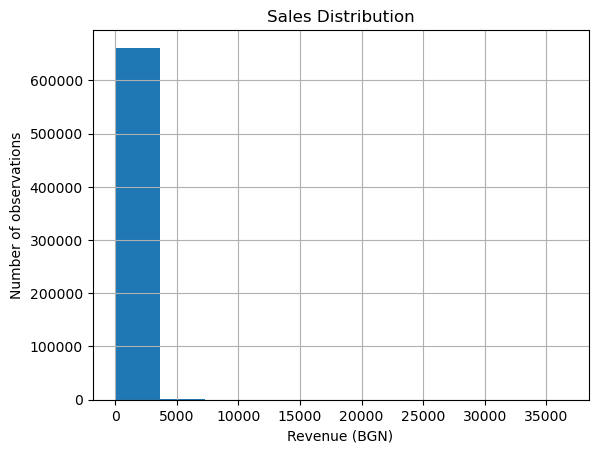

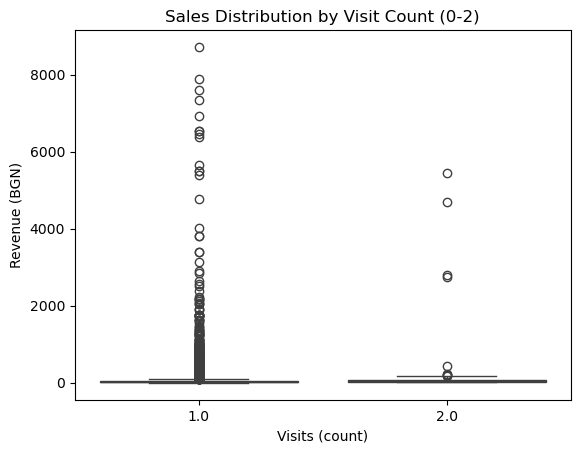

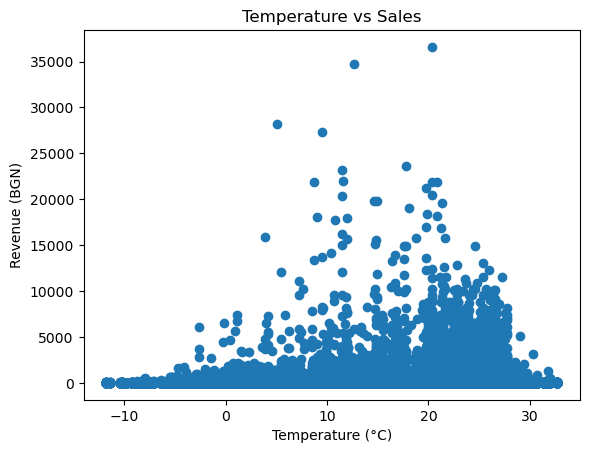

In [17]:

# SALES DISTRIBUTION
df["revenue_bgn"].hist()
plt.title("Sales Distribution")
plt.xlabel("Revenue (BGN)")
plt.ylabel("Number of observations")
plt.show()

# VISITS vs SALES
df_small = df[df["visits"].isin([0,1,2])]
sns.boxplot(x="visits", y="revenue_bgn", data=df_small)
plt.xlabel("Visits (count)")
plt.ylabel("Revenue (BGN)")
plt.title("Sales Distribution by Visit Count (0-2)")
plt.show()

# TEMPERATURE vs SALES
plt.scatter(df["temperature_celsius"], df["revenue_bgn"])
plt.title("Temperature vs Sales")
plt.xlabel("Temperature (°C)")
plt.ylabel("Revenue (BGN)")
plt.show()

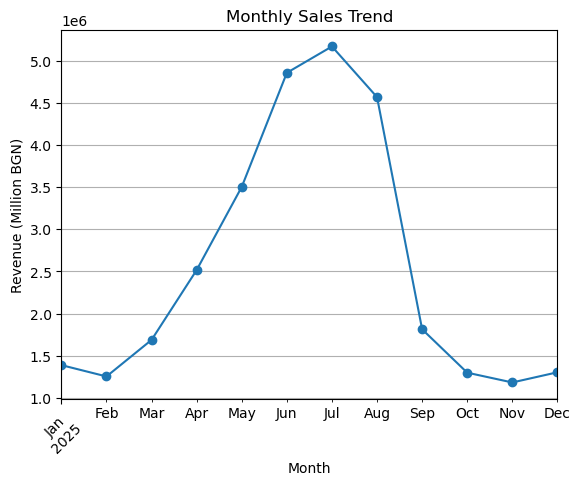

In [18]:
# ensure date is datetime
df["date"] = pd.to_datetime(df["date"])

# create month column
df["month"] = df["date"].dt.to_period("M")

# aggregate sales by month
monthly_sales = df.groupby("month")["revenue_bgn"].sum()

# plot
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Million BGN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

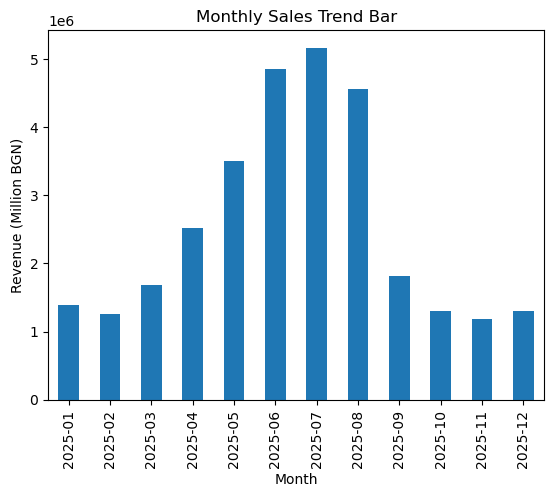

In [19]:
monthly_sales.plot(kind="bar")

plt.title("Monthly Sales Trend Bar")
plt.xlabel("Month")
plt.ylabel("Revenue (Million BGN)")
plt.show()

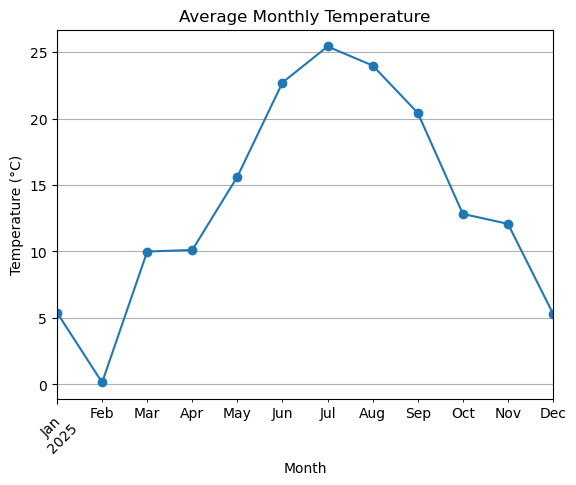

In [20]:
# ensure datetime
df["date"] = pd.to_datetime(df["date"])

# create month
df["month"] = df["date"].dt.to_period("M")

# average temperature per month
monthly_temp = df.groupby("month")["temperature_celsius"].mean()

# plot
monthly_temp.plot(marker="o")

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

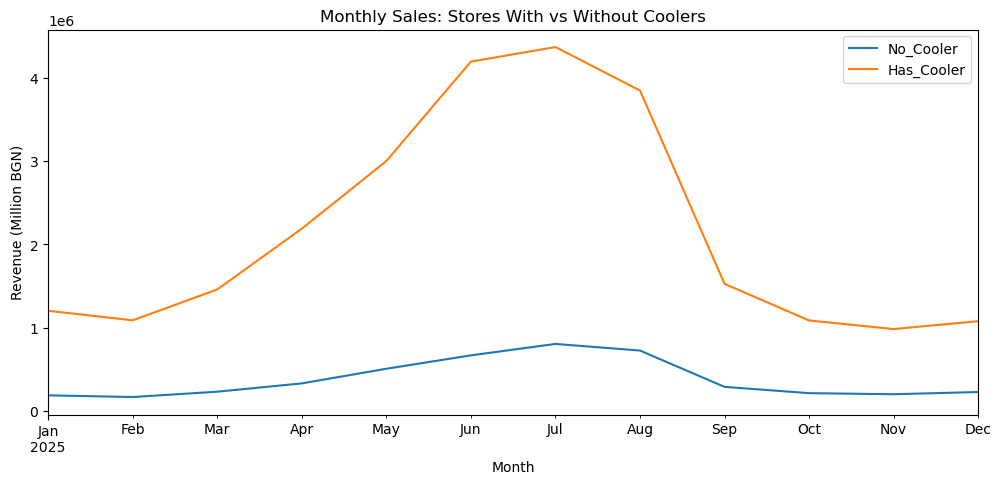

In [21]:
# 1. Cooler flag
cooler_flag = cooler.groupby("customer")["equipment_count"].sum().reset_index()
cooler_flag["has_cooler"] = (cooler_flag["equipment_count"] > 0).astype(int)

# 2. Merge
df2 = sales.merge(cooler_flag[["customer", "has_cooler"]],
                   on="customer",
                   how="left")

df2["has_cooler"] = df2["has_cooler"].fillna(0)

# 3. Date → month
df2["date"] = pd.to_datetime(df2["date"])
df2["month"] = df2["date"].dt.to_period("M")

# 4. Monthly aggregation
monthly = df2.groupby(["month", "has_cooler"])["revenue_bgn"].sum().reset_index()

# 5. Pivot
result = monthly.pivot(index="month",
                        columns="has_cooler",
                        values="revenue_bgn")

result.columns = ["No_Cooler", "Has_Cooler"]

# 6. Plot
result.plot(figsize=(12,5))
plt.title("Monthly Sales: Stores With vs Without Coolers")
plt.ylabel("Revenue (Million BGN)")
plt.xlabel("Month")
plt.show()

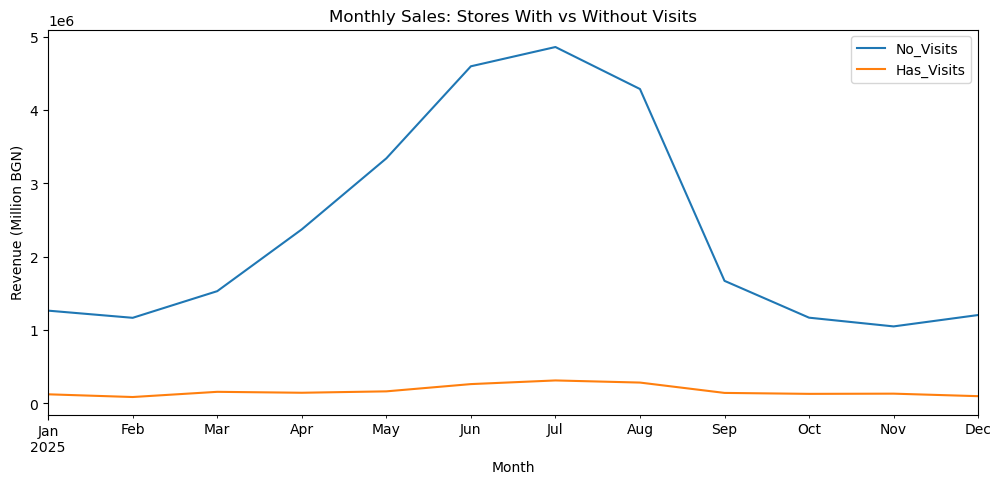

In [22]:
# 1. visits customer + date
vis = visits.copy()
vis["date"] = pd.to_datetime(vis["date"], errors="coerce", dayfirst=True)
vis["visits"] = pd.to_numeric(vis["visits"], errors="coerce")

# 2. Merge
vis_agg = vis.groupby(["customer", "date"])["visits"].sum().reset_index()

# 3. Merge
df2 = sales.merge(vis_agg, on=["customer", "date"], how="left")

# 4. No_Visits / Has_Visits
df2["has_visits"] = (df2["visits"].fillna(0) > 0).astype(int)

# 5. Date → month
df2["date"] = pd.to_datetime(df2["date"])
df2["month"] = df2["date"].dt.to_period("M")

# 6. Monthly aggregation
monthly = df2.groupby(["month", "has_visits"])["revenue_bgn"].sum().reset_index()

# 7. Pivot
result = monthly.pivot(index="month",
                        columns="has_visits",
                        values="revenue_bgn")

result.columns = ["No_Visits", "Has_Visits"]

# 8. Plot
result.plot(figsize=(12,5))
plt.title("Monthly Sales: Stores With vs Without Visits")
plt.ylabel("Revenue (Million BGN)")
plt.xlabel("Month")
plt.show()

In [23]:
# ensure types
visits["date"] = pd.to_datetime(visits["date"], errors="coerce", dayfirst=True)
visits["visits"] = pd.to_numeric(visits["visits"], errors="coerce")

# aggregate visits per customer-date
vis_agg = visits.groupby(["customer", "date"])["visits"].sum().reset_index()

# merge with sales
df2 = sales.merge(vis_agg, on=["customer", "date"], how="left")

# flag
df2["has_visits"] = (df2["visits"].fillna(0) > 0)

# TOTAL TURNOVER
totals = df2.groupby("has_visits")["revenue_bgn"].sum()

print(totals)

has_visits
False    28499634.46
True      2040902.24
Name: revenue_bgn, dtype: float64


# 7. STATISTICAL INFERENCE

To move beyond descriptive analysis, we apply statistical inference methods to evaluate relationships between key variables and sales performance.

We use three complementary approaches:
- Correlation analysis (linear associations)
- Hypothesis testing (mean differences across groups)
- Variance analysis (heterogeneity across segments)

## Correlation Analysis

We first examine pairwise linear relationships using Pearson correlation coefficients.

The results indicate weak but positive relationships between sales and both visits and temperature, while no strong linear dependencies are observed overall.

In [24]:
df[["revenue_bgn","visits","temperature_celsius"]].corr()

,revenue_bgn,visits,temperature_celsius
revenue_bgn,1.000000,0.044577,0.028014
visits,0.044577,1.000000,0.034029
temperature_celsius,0.028014,0.034029,1.000000


## T-Test Analysis

We test whether average sales differ significantly between high-visit and low-visit stores using an independent samples t-test.

This helps evaluate whether store visit intensity is associated with differences in sales performance.

We compare high-visit vs low-visit stores:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$ 

Result: p < 0.0001, significant difference.

High visit stores vs low visit stores

Objective:

Determine whether store visits significantly affect sales performance.

In [25]:
high = df[df["high_visit"] == True]["revenue_bgn"]
low = df[df["high_visit"] == False]["revenue_bgn"]

ttest_ind(high, low, nan_policy='omit')

TtestResult(statistic=np.float64(5.449510368505093), pvalue=np.float64(5.0526620324910335e-08), df=np.float64(662039.0))

## ANOVA Analysis

To assess heterogeneity across store segments, we perform a one-way ANOVA test.

This allows us to test whether mean sales differ significantly across categorical groups (Bronze, Silver, Gold).

We extend the comparison across multiple groups.

Testing differences across store segments:

$$
F = \frac{\text{Between-group variance}}{\text{Within-group variance}}
$$

Result: p = 0.0, strong evidence of heterogeneity.

Store segments (Bronze, Silver, Gold)
Regional performance groups

Objective:

Test whether differences in sales are statistically significant across categories.

In [26]:
groups = [g["revenue_bgn"].dropna() for _, g in df.groupby("Segment")]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(1767.4773742070329), pvalue=np.float64(0.0))

## Hypothesis Evaluation

Each hypothesis is evaluated based on p-values and statistical significance thresholds (α = 0.05).

# 8. REGRESSION MODELING

To quantify the impact of operational and environmental factors on sales, we estimate a sequence of regression models with increasing complexity.

The model is defined as:

Sales = f(visits, temperature, humidity, equipment, store characteristics)

Model Objective:
Estimate the magnitude of each driver
Identify statistically significant predictors
Measure overall explanatory power (R²)
Interpretation:
Positive coefficients indicate drivers that increase sales
Negative coefficients indicate inhibitory effects
Statistical significance determines reliability of predictors

    1. Model Specification
We estimate:

$$
\log(y_{it}) = \beta_0 + \beta_1 \cdot visits_{it} + \beta_2 \cdot temperature_{rt} + \beta_3 \cdot humidity_{rt} + \beta_4 \cdot equipment_i + u_{it}
$$

Why log-transform?

    - Stabilizes variance
    - Reduces skewness
    - Coefficients become elasticities

    2. Results Summary

    - Temperature: positive, significant
    - Humidity: negative, significant
    - Equipment count: strong positive effect
    -Visits: not significant in OLS (but see causal model below)

Handling Missing Visits

A large portion of visit data is missing. Instead of removing these observations, missing values are interpreted as absence of recorded visits rather than true missingness.

Thus, missing visit values are imputed as zero to preserve dataset size and avoid selection bias.

## Baseline Model

We first estimate a simple OLS regression to measure the direct relationship between sales and key drivers.

This model provides an initial benchmark but does not account for time dynamics or non-linear effects.

In [27]:
# CLEAN DATA
# махаме отрицателни и нулеви продажби (задължително за log)
df = df[df["revenue_bgn"] > 0].copy()

# махаме липсващи стойности за ключови променливи
df = df.dropna(subset=[
    "temperature_celsius",
    "humidity_percent",
    "equipment_count"
])

df["visits"] = df["visits"].fillna(0)

# TARGET VARIABLE
df["log_sales"] = np.log(df["revenue_bgn"])

# 3. FEATURES (X)
X = df[[
    "visits",
    "temperature_celsius",
    "humidity_percent",
    "equipment_count"
]]
# ако има NaN 
X = X.fillna(0)

X = sm.add_constant(X)
y = df["log_sales"]
model = sm.OLS(y, X, missing="drop").fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     9278.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:31:35   Log-Likelihood:            -8.2495e+05
No. Observations:              526335   AIC:                         1.650e+06
Df Residuals:                  526330   BIC:                         1.650e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.5969    

## Extended Model with Additional Features

We extend the baseline model by including lagged variables, interaction terms, and temporal controls to capture dynamic and non-linear effects.

This improves model flexibility and captures more realistic sales behavior over time.

In [28]:
import statsmodels.api as sm
import numpy as np

# TARGET
y = df["log_sales"].copy()

# FEATURES
X = df[[
    "visits",
    "visits_lag1",
    "temperature_celsius",
    "temp_sq",
    "humidity_percent",
    "equipment_count",
    "temp_x_visits",
    "day_of_week",
    "month"
]].copy()

# FORCE NUMERIC
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# month → int (if Period)
if str(X["month"].dtype).startswith("period"):
    X["month"] = X["month"].astype(int)

# DUMMIES
X = pd.get_dummies(X, columns=["month"], drop_first=True)

# FINAL CLEAN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# align y !!!
y = y.loc[X.index]

# ensure y numeric
y = pd.to_numeric(y, errors="coerce")
y = y.loc[X.index]

print("OBJECT COLUMNS:", X.select_dtypes(include=["object"]).columns)

X = sm.add_constant(X)

model_ext = sm.OLS(y, X).fit()

print(model_ext.summary())

OBJECT COLUMNS: Index([], dtype='object')
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     10.29
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           4.01e-14
Time:                        03:31:36   Log-Likelihood:                -2626.1
No. Observations:                1605   AIC:                             5270.
Df Residuals:                    1596   BIC:                             5319.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

## Fixed Effects Model (Controlling for Unobserved Heterogeneity)

To address unobserved heterogeneity across stores, we estimate a fixed effects model using within-store variation.

This approach removes time-invariant differences such as store location and customer base, allowing us to isolate the effect of time-varying drivers on sales.

In [29]:
# copy dataset safely
df_fe = df.copy()

# ensure no missing key columns
cols = [
    "log_sales",
    "visits",
    "visits_lag1",
    "temperature_celsius",
    "humidity_percent",
    "equipment_count"
]

df_fe = df_fe.dropna(subset=cols)

# -------------------------
# WITHIN TRANSFORMATION
# -------------------------

grouped = df_fe.groupby("customer")

df_fe["log_sales_dm"] = df_fe["log_sales"] - grouped["log_sales"].transform("mean")

X_vars = [
    "visits",
    "visits_lag1",
    "temperature_celsius",
    "humidity_percent",
    "equipment_count"
]

for col in X_vars:
    df_fe[col + "_dm"] = df_fe[col] - grouped[col].transform("mean")

# -------------------------
# MODEL
# -------------------------

import statsmodels.api as sm

X = df_fe[[col + "_dm" for col in X_vars]]
X = sm.add_constant(X)

y = df_fe["log_sales_dm"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_sales_dm   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     191.1
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          1.64e-162
Time:                        03:31:36   Log-Likelihood:                -50034.
No. Observations:               38082   AIC:                         1.001e+05
Df Residuals:                   38077   BIC:                         1.001e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1.73

C:\Users\radio\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
C:\Users\radio\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '


# 9. ADVANCED INSIGHTS

To deepen the analysis, we explore:

    1. Interaction Effects

We analyze whether combined effects exist between variables:

Visits * Weather conditions
Store execution * Store type

    2. Lag Effects

We test whether past operational activity influences future sales:

Previous visits -> current sales

    3. Seasonality Effects

We evaluate temporal patterns:

Weekend vs weekday behavior
Holiday vs non-holiday effects

Interpretation of Coefficients

Since the dependent variable is log-transformed, coefficients can be interpreted as approximate percentage changes in sales.

Key findings include:
- Temperature has a positive effect on sales, consistent with higher demand in warmer conditions
- Equipment availability shows the strongest and most stable positive impact
- Visits are significant in extended models, but their interpretation is affected by potential endogeneity

Visits Effect Interpretation

The effect of visits is sensitive to model specification.

While insignificant in baseline models, it becomes more pronounced in extended specifications. However, potential endogeneity implies that visits may be correlated with unobserved store performance.

# 10. CONCLUSION

This study identifies key drivers of FMCG beverage sales using statistical and econometric methods.

The results suggest that:
- Store execution quality is the most important driver of sales
- Weather conditions significantly affect demand patterns
- Store visits show mixed effects depending on model specification

From a business perspective, the findings highlight the importance of combining operational execution with environmental awareness in demand planning.

Overall, the analysis demonstrates how combining statistical inference with econometric modeling provides deeper insights into sales dynamics.